In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
import re
import warnings
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import string
from bs4 import BeautifulSoup
from google.colab import drive
from keras.layers import Dropout
from keras.optimizers import SGD, Adam
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.tokenize.toktok import ToktokTokenizer
from scipy import stats
from sklearn.model_selection import train_test_split
from tensorflow.keras import losses
from tensorflow.keras.layers import (LSTM, Bidirectional, Dense, Embedding, Flatten)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

nltk.download('punkt')
nltk.download("stopwords")
warnings.filterwarnings("ignore")
drive.mount('/content/drive')

# text pre-processing functions
def strip_html_tags(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

def remove_urls(text):
    return re.sub(r'http\S+', '', text)

def remove_stopwords_and_punctuations(text):
    stop = set(stopwords.words('english')) # get English stop words
    punctuation = list(string.punctuation)
    stop.update(punctuation)
    final_text = []
    for word in text.split():
        if word.strip().lower() not in stop and word.strip().lower().isalpha():
            final_text.append(word.strip().lower())
    return " ".join(final_text)

def clean_text(text):
    text = strip_html_tags(text)
    text = remove_urls(text)
    text = remove_stopwords_and_punctuations(text)
    return text

# early stop condition
class EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, monitor='loss', min_delta=0.001, patience=3):
        super(EarlyStopping, self).__init__()
        self.monitor = monitor
        self.min_delta = min_delta
        self.patience = patience
        self.wait = 0
        self.stopped_epoch = 0
        self.best = np.Inf if 'loss' in monitor else -np.Inf
        self.monitor_op = np.less if 'loss' in monitor else np.greater

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            pass

        if self.monitor_op(current - self.min_delta, self.best):
            self.best = current
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience or epoch >= 9:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print(f'\n\nTraining stopped after {epoch+1} epochs.')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Mounted at /content/drive


## **LSTM)**
**1 layer: 64 units**

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Epoch 1/10
500/500 [==============================] - 63s 118ms/step - loss: 0.1396 - accuracy: 0.8050
Epoch 2/10
500/500 [==============================] - 25s 51ms/step - loss: 0.0676 - accuracy: 0.9132
Epoch 3/10
500/500 [==============================] - 14s 27ms/step - loss: 0.0543 - accuracy: 0.9349
Epoch 4/10
500/500 [==============================] - 11s 22ms/step - loss: 0.0624 - accuracy: 0.9299
Epoch 5/10
500/500 [==============================] - 8s 15ms/step - loss: 0.0638 - accuracy: 0.9306
Epoch 6/10
500/500 [==============================] - 7s 14ms/step - loss: 0.0588 - accuracy: 0.9364
Epoch 7/10
500/500 [==============================] - 6s 11ms/step - loss: 0.0590 - accuracy: 0.9371
Epoch 8/10
500/500 [==============================] - 7s 15ms/step - loss: 0.0591 - accuracy: 0.9374
Epoch 9/10
500/500 [==============================] - 6s 12ms/step - loss: 0.0570 - accuracy: 0.9402
Epoch 10/10
500/500 [==============================] - 6s 12ms/step - loss: 0.0557 - a

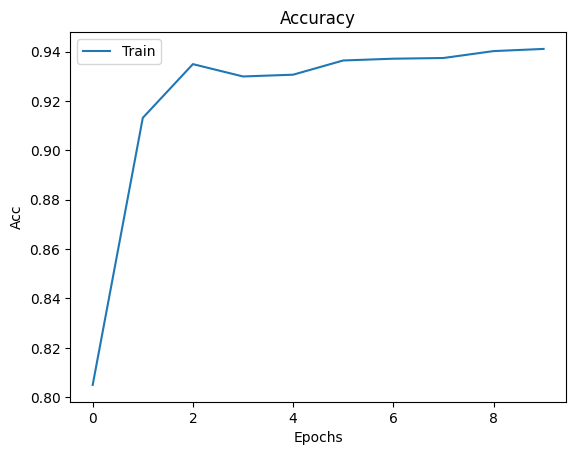

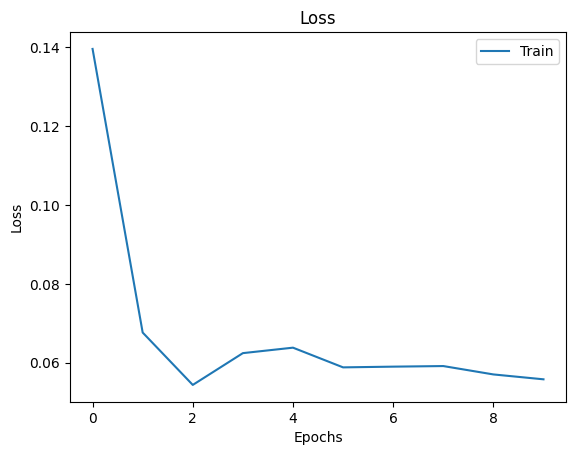

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(LSTM(units=64, return_sequences=True)) # LSTM layer
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1)  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**1 layer: 64 units**

Epoch 1/10
500/500 [==============================] - 44s 83ms/step - loss: 0.1485 - accuracy: 0.7990
Epoch 2/10
500/500 [==============================] - 19s 38ms/step - loss: 0.0733 - accuracy: 0.9088
Epoch 3/10
500/500 [==============================] - 11s 23ms/step - loss: 0.0695 - accuracy: 0.9216
Epoch 4/10
500/500 [==============================] - 9s 19ms/step - loss: 0.0827 - accuracy: 0.9122
Epoch 5/10
500/500 [==============================] - 8s 16ms/step - loss: 0.0827 - accuracy: 0.9133
Epoch 6/10
500/500 [==============================] - 10s 19ms/step - loss: 0.0832 - accuracy: 0.9134
Epoch 7/10
500/500 [==============================] - 8s 15ms/step - loss: 0.0798 - accuracy: 0.9175
Epoch 8/10
500/500 [==============================] - 8s 17ms/step - loss: 0.0795 - accuracy: 0.9182
Epoch 9/10
500/500 [==============================] - 7s 14ms/step - loss: 0.0769 - accuracy: 0.9210
Epoch 10/10
500/500 [==============================] - 8s 17ms/step - loss: 0.0738 - ac

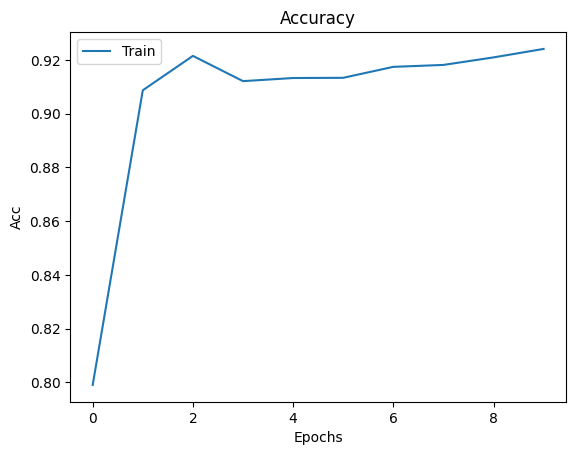

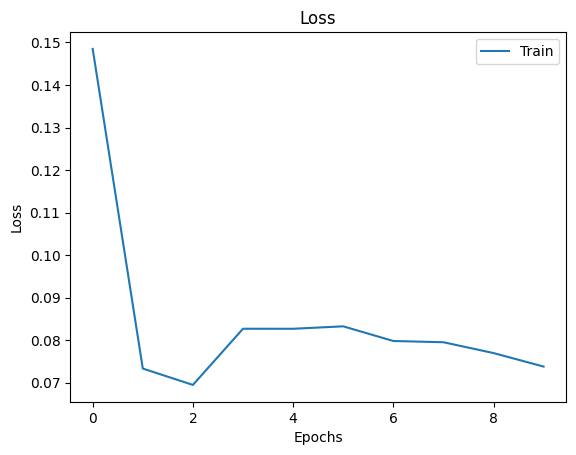

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=64, return_sequences=True))) # Bi-LSTM layer
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1)  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**layer 1: 64 units**

**layer 2: 64 units**

Epoch 1/10
500/500 [==============================] - 48s 85ms/step - loss: 0.4980 - accuracy: 0.5005
Epoch 2/10
500/500 [==============================] - 23s 47ms/step - loss: 0.4993 - accuracy: 0.5007
Epoch 3/10
500/500 [==============================] - 16s 32ms/step - loss: 0.4993 - accuracy: 0.5007
Epoch 4/10
500/500 [==============================] - ETA: 0s - loss: 0.4993 - accuracy: 0.5007

Training stopped after 4 epochs.
500/500 [==============================] - 14s 27ms/step - loss: 0.4993 - accuracy: 0.5007

Performance on test data:
782/782 [==============================] - 8s 9ms/step - loss: 0.5007 - accuracy: 0.4993


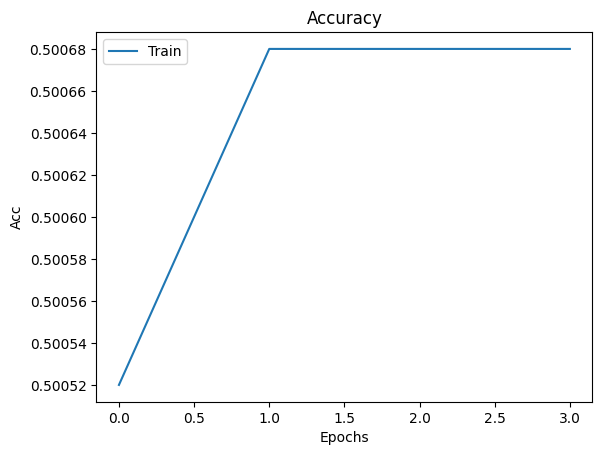

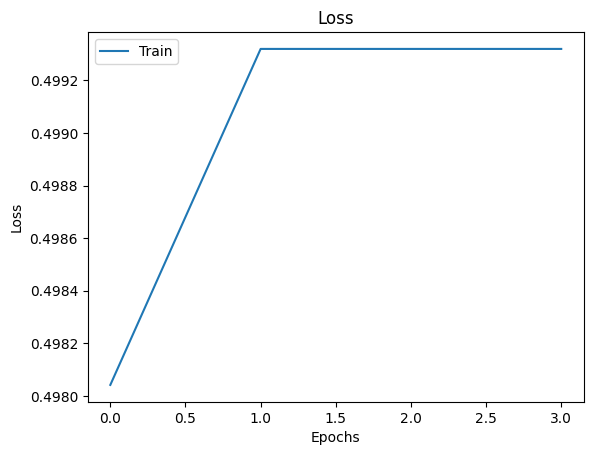

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=64, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**

**layer 1: 64 units**

**layer 2: 64 units**

**dropout 0.3**

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Epoch 1/10
500/500 [==============================] - 72s 122ms/step - loss: 0.1466 - accuracy: 0.7946
Epoch 2/10
500/500 [==============================] - 30s 61ms/step - loss: 0.0703 - accuracy: 0.9086
Epoch 3/10
500/500 [==============================] - 19s 38ms/step - loss: 0.0470 - accuracy: 0.9426
Epoch 4/10
500/500 [==============================] - 15s 31ms/step - loss: 0.0453 - accuracy: 0.9471
Epoch 5/10
500/500 [==============================] - 15s 29ms/step - loss: 0.0662 - accuracy: 0.9290
Epoch 6/10
500/500 [==============================] - 14s 27ms/step - loss: 0.0862 - accuracy: 0.9104
Epoch 7/10
499/500 [============================>.] - ETA: 0s - loss: 0.0981 - accuracy: 0.8984

Training stopped after 7 epochs.
500/500 [==============================] - 12s 24ms/step - loss: 0.0981 - accuracy: 0.8984

Performance on test data:
782/782 [==============================] - 9s 10ms/step - loss: 0.1931 - accuracy: 0.8038


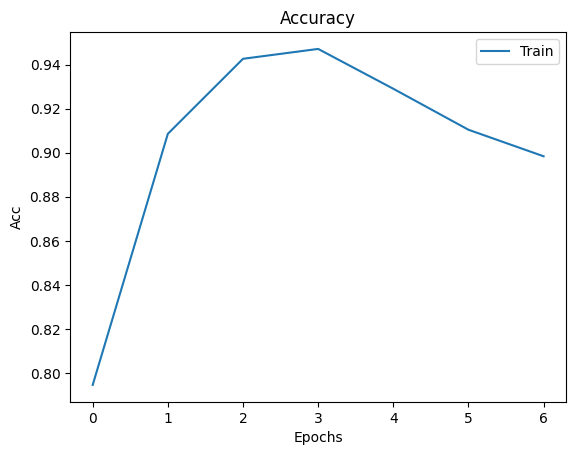

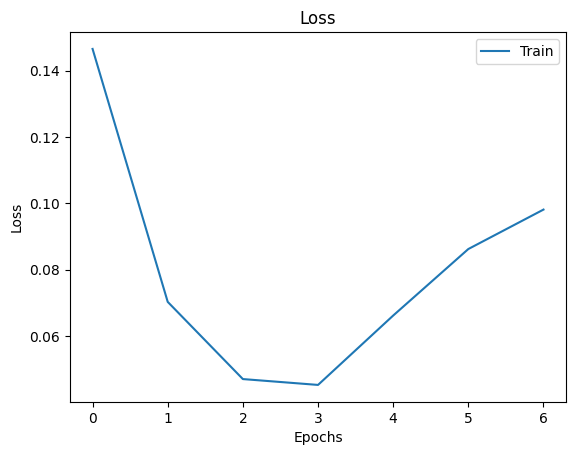

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=64, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
model.add(Dropout(0.3))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**

**layer 1: 64 units**

**layer 2: 64 units**

**lr = 0.001**

Epoch 1/10
500/500 [==============================] - 50s 87ms/step - loss: 0.1318 - accuracy: 0.8086
Epoch 2/10
500/500 [==============================] - 22s 45ms/step - loss: 0.0669 - accuracy: 0.9124
Epoch 3/10
500/500 [==============================] - 17s 33ms/step - loss: 0.0397 - accuracy: 0.9523
Epoch 4/10
500/500 [==============================] - 15s 29ms/step - loss: 0.0267 - accuracy: 0.9692
Epoch 5/10
500/500 [==============================] - 12s 24ms/step - loss: 0.0207 - accuracy: 0.9761
Epoch 6/10
500/500 [==============================] - 11s 23ms/step - loss: 0.0172 - accuracy: 0.9810
Epoch 7/10
500/500 [==============================] - 12s 24ms/step - loss: 0.0148 - accuracy: 0.9838
Epoch 8/10
500/500 [==============================] - 11s 22ms/step - loss: 0.0130 - accuracy: 0.9857
Epoch 9/10
500/500 [==============================] - 11s 23ms/step - loss: 0.0131 - accuracy: 0.9850
Epoch 10/10
498/500 [============================>.] - ETA: 0s - loss: 0.0122 - ac

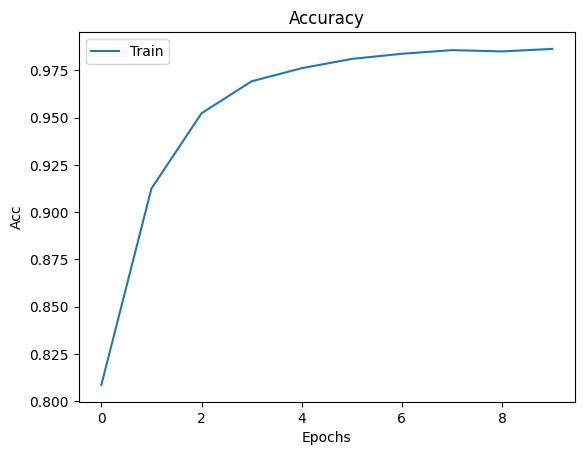

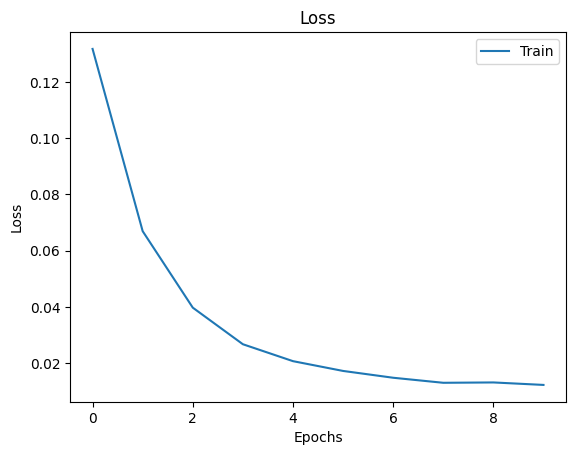

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=64, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**layer 1: 64 units**

**layer 2: 32 units**

Epoch 1/10
500/500 [==============================] - 49s 87ms/step - loss: 0.1370 - accuracy: 0.8076
Epoch 2/10
500/500 [==============================] - 24s 48ms/step - loss: 0.0641 - accuracy: 0.9173
Epoch 3/10
500/500 [==============================] - 16s 32ms/step - loss: 0.0386 - accuracy: 0.9520
Epoch 4/10
500/500 [==============================] - 14s 28ms/step - loss: 0.0313 - accuracy: 0.9615
Epoch 5/10
500/500 [==============================] - 12s 23ms/step - loss: 0.0273 - accuracy: 0.9681
Epoch 6/10
500/500 [==============================] - 12s 23ms/step - loss: 0.0342 - accuracy: 0.9598
Epoch 7/10
500/500 [==============================] - 12s 23ms/step - loss: 0.0332 - accuracy: 0.9613
Epoch 8/10
500/500 [==============================] - ETA: 0s - loss: 0.0313 - accuracy: 0.9639

Training stopped after 8 epochs.
500/500 [==============================] - 12s 24ms/step - loss: 0.0313 - accuracy: 0.9639

Performance on test data:
782/782 [=============================

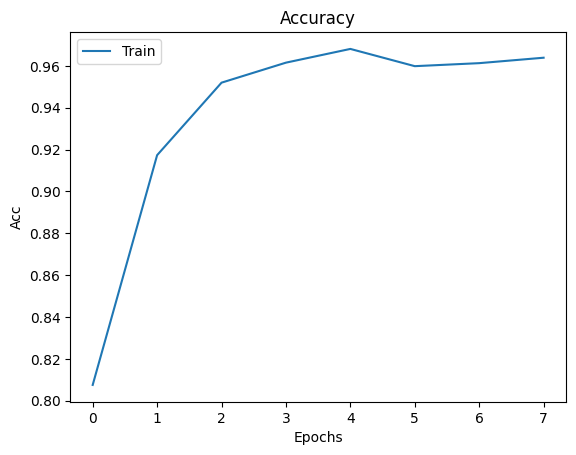

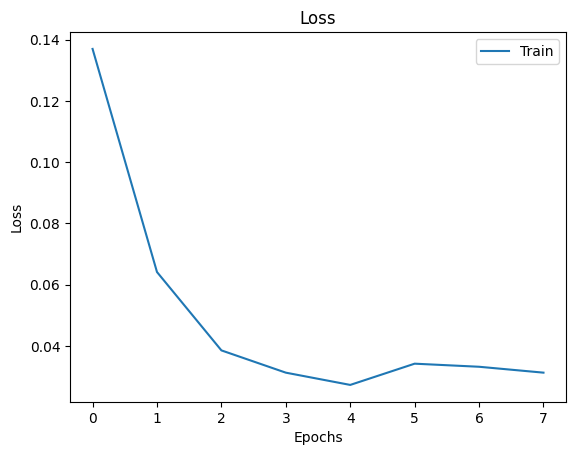

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=64, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=32, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**layer 1: 32 units**

**layer 2: 32 units**

Epoch 1/10
500/500 [==============================] - 51s 86ms/step - loss: 0.1310 - accuracy: 0.8123
Epoch 2/10
500/500 [==============================] - 22s 44ms/step - loss: 0.0618 - accuracy: 0.9208
Epoch 3/10
500/500 [==============================] - 16s 32ms/step - loss: 0.0366 - accuracy: 0.9551
Epoch 4/10
500/500 [==============================] - 13s 26ms/step - loss: 0.0265 - accuracy: 0.9680
Epoch 5/10
500/500 [==============================] - 13s 25ms/step - loss: 0.0253 - accuracy: 0.9698
Epoch 6/10
500/500 [==============================] - 11s 22ms/step - loss: 0.0253 - accuracy: 0.9704
Epoch 7/10
500/500 [==============================] - 12s 24ms/step - loss: 0.0241 - accuracy: 0.9720
Epoch 8/10
500/500 [==============================] - 10s 20ms/step - loss: 0.0237 - accuracy: 0.9727
Epoch 9/10
500/500 [==============================] - 11s 21ms/step - loss: 0.0241 - accuracy: 0.9723
Epoch 10/10
500/500 [==============================] - 11s 22ms/step - loss: 0.022

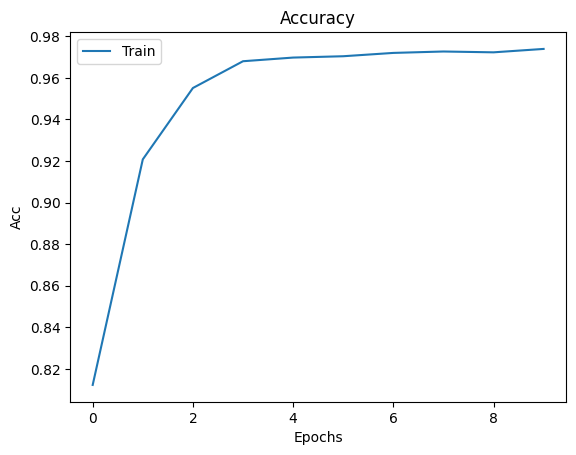

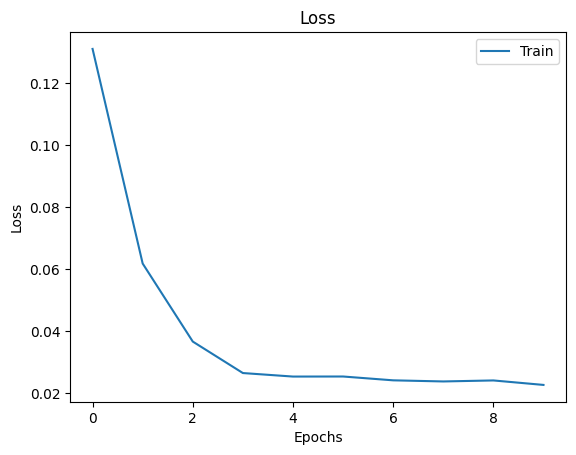

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=32, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=32, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**layer 1: 8 units**

**layer 2: 8 units**

Epoch 1/10
500/500 [==============================] - 50s 89ms/step - loss: 0.1278 - accuracy: 0.8175
Epoch 2/10
500/500 [==============================] - 24s 48ms/step - loss: 0.0575 - accuracy: 0.9258
Epoch 3/10
500/500 [==============================] - 17s 33ms/step - loss: 0.0329 - accuracy: 0.9600
Epoch 4/10
500/500 [==============================] - 14s 29ms/step - loss: 0.0237 - accuracy: 0.9718
Epoch 5/10
500/500 [==============================] - 12s 24ms/step - loss: 0.0189 - accuracy: 0.9779
Epoch 6/10
500/500 [==============================] - 12s 24ms/step - loss: 0.0150 - accuracy: 0.9828
Epoch 7/10
500/500 [==============================] - 11s 22ms/step - loss: 0.0134 - accuracy: 0.9848
Epoch 8/10
500/500 [==============================] - 11s 22ms/step - loss: 0.0148 - accuracy: 0.9827
Epoch 9/10
500/500 [==============================] - 11s 22ms/step - loss: 0.0151 - accuracy: 0.9826
Epoch 10/10
499/500 [============================>.] - ETA: 0s - loss: 0.0145 - ac

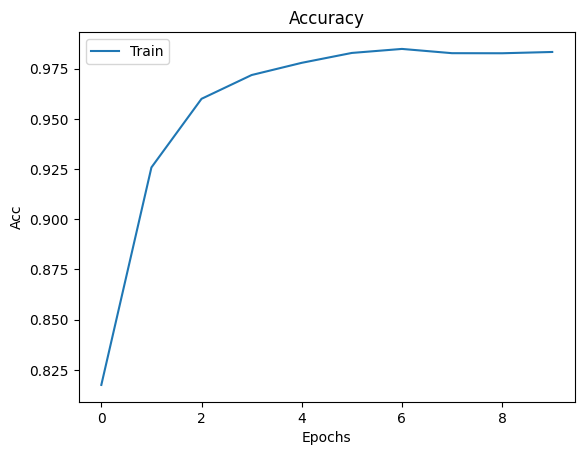

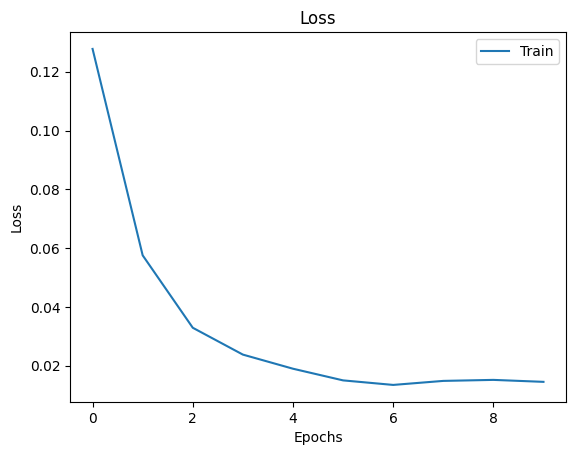

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=8, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=8, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**layer 1: 256 units**

**layer 2: 128 units**

Epoch 1/10
500/500 [==============================] - 52s 93ms/step - loss: 0.4985 - accuracy: 0.5005
Epoch 2/10
500/500 [==============================] - 30s 60ms/step - loss: 0.4993 - accuracy: 0.5007
Epoch 3/10
500/500 [==============================] - 23s 46ms/step - loss: 0.4993 - accuracy: 0.5007
Epoch 4/10
500/500 [==============================] - ETA: 0s - loss: 0.4993 - accuracy: 0.5007

Training stopped after 4 epochs.
500/500 [==============================] - 20s 41ms/step - loss: 0.4993 - accuracy: 0.5007

Performance on test data:
782/782 [==============================] - 12s 13ms/step - loss: 0.5007 - accuracy: 0.4993


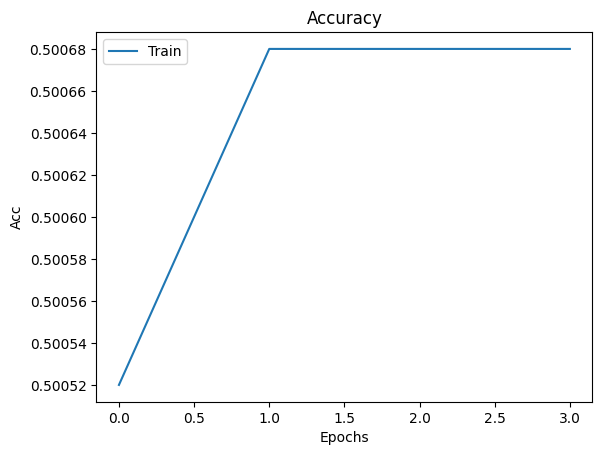

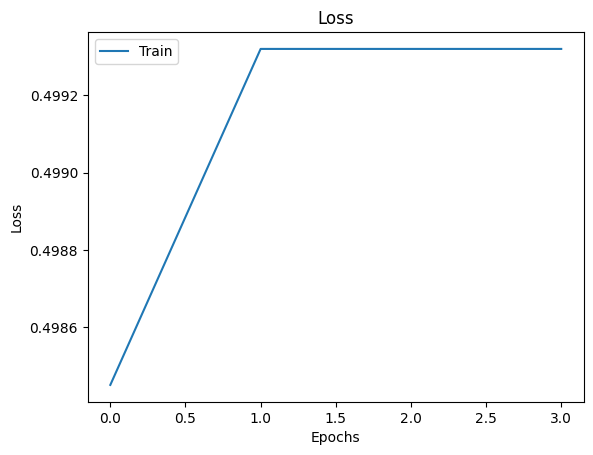

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=256, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=128, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## **Bi-LSTM)**
**layer 1: 256 units**

**layer 2: 128 units**

**lr = 0.001**

Epoch 1/10
500/500 [==============================] - 56s 100ms/step - loss: 0.1338 - accuracy: 0.8060
Epoch 2/10
500/500 [==============================] - 28s 56ms/step - loss: 0.0679 - accuracy: 0.9117
Epoch 3/10
500/500 [==============================] - 24s 48ms/step - loss: 0.0445 - accuracy: 0.9450
Epoch 4/10
500/500 [==============================] - 21s 42ms/step - loss: 0.0310 - accuracy: 0.9633
Epoch 5/10
500/500 [==============================] - 22s 43ms/step - loss: 0.0234 - accuracy: 0.9726
Epoch 6/10
500/500 [==============================] - 21s 42ms/step - loss: 0.0194 - accuracy: 0.9772
Epoch 7/10
500/500 [==============================] - 21s 41ms/step - loss: 0.0166 - accuracy: 0.9811
Epoch 8/10
500/500 [==============================] - 20s 40ms/step - loss: 0.0156 - accuracy: 0.9817
Epoch 9/10
500/500 [==============================] - 19s 39ms/step - loss: 0.0141 - accuracy: 0.9845
Epoch 10/10
500/500 [==============================] - 20s 39ms/step - loss: 0.01

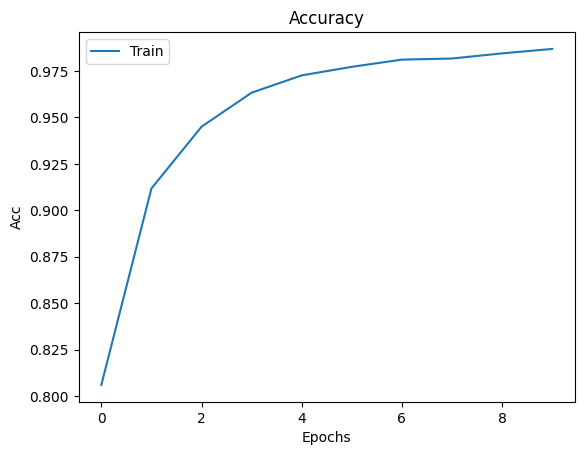

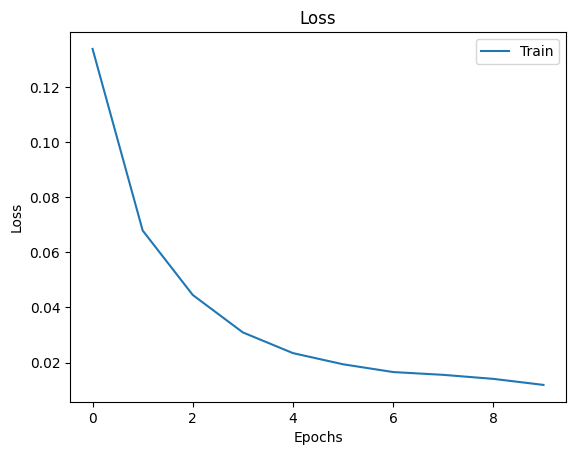

In [ ]:
# load dataset
dataset = pd.read_csv("/content/drive/MyDrive/IMDB_Dataset.csv")

# labels to binary
dataset.sentiment = [1 if each == "positive" else 0 for each in dataset.sentiment]

# text cleaning for 'review' column
dataset['clean_review'] = dataset['review'].apply(clean_text)

# separate features and target variable
dataset_copy = dataset.copy()
sentiments = dataset_copy['sentiment'].values
reviews = dataset_copy['clean_review']

# dataset splits to train and test set
x_train, x_test, y_train, y_test = train_test_split(reviews, sentiments, test_size=0.5, random_state=42)

# BERT tokenizer for converting each word to scalar vector
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
x_train_tokens = x_train.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))
x_test_tokens = x_test.apply(lambda text: bert_tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=126))

# padding sequences to common length
max_seq_length = max(len(token) for token in x_train_tokens)
x_train_padded = pad_sequences(x_train_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")
x_test_padded = pad_sequences(x_test_tokens, maxlen=max_seq_length, dtype="long", value=0, truncating="post", padding="post")

# creating LSTM model
model = Sequential()
model.add(Embedding(input_dim=bert_tokenizer.vocab_size, output_dim=100, input_length=max_seq_length, name='embedding_layer')) # add Embedding layer
model.add(Bidirectional(LSTM(units=256, return_sequences=True))) # Bi-LSTM layers
model.add(Bidirectional(LSTM(units=128, return_sequences=True)))
# fc layer
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='accuracy', min_delta=0.001, patience=3)
training_history = model.fit(x_train_padded, y_train, epochs=10, batch_size=50, verbose=1, callbacks=[early_stop])  # train model
print("\nPerformance on test data:")
result = model.evaluate(x_test_padded, y_test) # evaluate model

# plot train acc
epochs = range(0, len(training_history.history['accuracy']))
plt.figure()
plt.plot(epochs, training_history.history["accuracy"], label="Train")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("Epochs")
plt.legend()
plt.show()

# plot train loss
plt.figure()
plt.plot(epochs, training_history.history["loss"], label="Train")
plt.title("Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()